# Margin-Debt -- a quantitative teardown
### 65 forward-years * HAC OLS * YoY terciles * record-high event * sub-periods * timing rule * synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* Real data: NYSE/FINRA December margin debt (hardcoded, 1959-2025) x S&P 500 month-end **price-only** (`^GSPC_split_only`). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

> 💡 *In plain words* asides translate each result back to intuition.

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from margin_debt import data, strategy as st

def _have_cache():
    try:
        data.build_panel(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
if HAVE_REAL:
    panel = data.build_panel(fetch=False)
    print(f"Real panel: {len(panel)} forward-years "
          f"({panel['year'].min()}-{panel['year'].max()})")
else:
    panel = None
    print("No ^GSPC cache -- frozen headline numbers from R dict will be used")

from scipy import stats as scipy_stats


Real panel: 65 forward-years (1960-2024)


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n': 65, 'year_start': 1960, 'year_end': 2024, 'reg_beta_pct': -2.23, 'reg_t': -1.35, 'reg_r2': 0.023, 'ter_low': 11.9, 'ter_mid': 4.9, 'ter_high': 9.0, 'ter_spread': -2.9, 'ter_t': -0.67, 'rec_mean': 6.6, 'nonrec_mean': 11.1, 'rec_diff': -4.5, 'rec_up': 62.9, 'uncond_up': 73.9, 'rec_t': -1.22, 'sub1_t': -1.62, 'sub2_t': -0.56, 'sub3_t': -1.44, 'bah_ann': 7.53, 'strat_net_ann': 6.51, 'years_cash': 8, 'shortfall_pp': -1.02, 'y2000': -17.3, 'y2007': -40.1, 'y2021': -9.7, 'fp': '3f24fa7a68df'}


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Contrarian (negative) slope, but HAC *t* = **-1.35**; tercile *t* = **-0.67**; record-event *t* = **-1.22**. Right sign, never clears \|t\| >= 2. |
| **Tradability** | `MIRAGE` | 'Cash after a surge' rule trails buy-and-hold by **-1.0pp/yr** net. |

> Margin debt is dollar-denominated and scales with portfolio values: it rises *because* prices rose. A coincident by-product is a poor leading indicator.

## 1 - The claim, steelmanned

Let $Y_{t+1}$ be the forward 12-month S&P return and $g_t$ be the standardized YoY margin-debt growth through December $t$. The contrarian hypotheses:

- **H1 (slope).** In $Y_{t+1} = \alpha + \beta\, g_t + \varepsilon$, we have $\beta < 0$ with HAC $|t| \ge 2$.
- **H2 (terciles).** Mean forward return in the top YoY-growth tercile is below the bottom tercile.
- **H3 (record event).** Forward return after a fresh all-time-high margin print is below the unconditional mean / base rate.

We find the *signs* of H1-H3 all point the contrarian way, but none reaches significance.

## 2 - So what? -- what rides on each answer

If H1-H3 held with real *t*-stats, margin debt would be a free monthly macro timing signal. The interesting finding is *why* the chart looks predictive: margin-debt records cluster at the end of long bull runs, so a handful of vivid post-record crashes (2000, 2007, 2021) anchor the narrative while the many records that kept rising are quietly forgotten -- a textbook anecdote-vs-base-rate problem.

## 3 - How we'd know -- the protocol

- **Data.** December NYSE/FINRA margin debt (hardcoded in `data.py`); S&P 500 month-end close, price-only (`^GSPC_split_only`).
- **Signal.** Standardized YoY margin growth through December $t$.
- **Lag.** One-month reporting/execution lag (enter end-January of $t{+}1$); forward return is the next 12 months.
- **Inference.** HAC (Newey-West) OLS slope *t*; Welch *t* for tercile and record-event group differences; sub-period splits.
- **Positive control.** Synthetic tape with a planted contrarian `predictive_beta`.
- **Honesty.** Price-only returns labeled (conservative for a contrarian 'sell' claim); single index, no survivorship selection.

## 4 - The teardown

### 4a - The HAC predictive regression

Forward 12m return on standardized YoY margin growth, Newey-West *t*.

In [3]:
if HAVE_REAL:
    reg = st.predictive_regression(panel)
    beta, t, r2, n = reg['beta'], reg['beta_t'], reg['r2'], reg['n']
else:
    beta, t, r2, n = R['reg_beta_pct']/100, R['reg_t'], R['reg_r2'], R['n']

print('=== Contrarian predictive regression ===')
print(f'  slope (per +1 sigma): {beta*100:+.2f}% forward return')
print(f'  HAC t = {t:+.3f}   R^2 = {r2:.3f}   n = {n}')
print()
print(f'  Contrarian sign: {"YES" if beta < 0 else "NO"}')
print(f'  Clears |t| >= 2: {"YES" if abs(t) >= 2 else "NO -- verdict WEAK"}')

=== Contrarian predictive regression ===
  slope (per +1 sigma): -2.23% forward return
  HAC t = -1.352   R^2 = 0.023   n = 65

  Contrarian sign: YES
  Clears |t| >= 2: NO -- verdict WEAK


> 💡 *In plain words:* the line tilts the right way (more leverage, slightly lower next-year return) but the tilt is buried in the noise. *R²* ≈ 0.02 -- margin growth explains ~2% of next year's return.

### 4b - Terciles: surging vs contracting leverage

Sort years into thirds by YoY margin growth; compare forward returns.

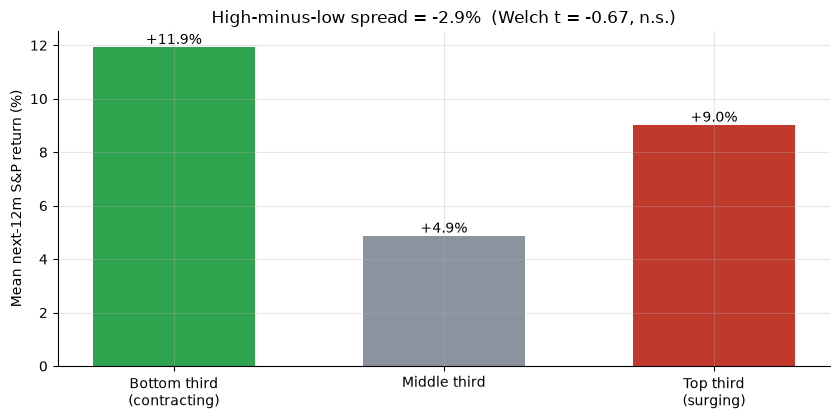

High - Low: -2.9%  Welch t = -0.67


In [4]:
if HAVE_REAL:
    ter = st.tercile_forward_returns(panel)
    lo, mi, hi = ter['low_mean']*100, ter['mid_mean']*100, ter['high_mean']*100
    spr, wt = ter['spread_high_minus_low']*100, ter['welch_t']
else:
    lo, mi, hi = R['ter_low'], R['ter_mid'], R['ter_high']
    spr, wt = R['ter_spread'], R['ter_t']

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Bottom third\n(contracting)', 'Middle third', 'Top third\n(surging)'],
              [lo, mi, hi], color=[GREEN, GREY, RED], width=0.6)
ax.set_ylabel('Mean next-12m S&P return (%)')
ax.set_title(f'High-minus-low spread = {spr:+.1f}%  (Welch t = {wt:+.2f}, n.s.)')
for b, v in zip(bars, [lo, mi, hi]):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'High - Low: {spr:+.1f}%  Welch t = {wt:+.2f}')

The high-growth tercile trails the low-growth tercile (the contrarian direction) but Welch *t* = -0.67 -- noise. Note the **middle** tercile is the weakest, which is the opposite of a clean monotonic relationship.

### 4c - The record-high event test (the newspaper headline)

Forward return in fresh-all-time-high margin years vs all others.

In [5]:
if HAVE_REAL:
    rec = st.record_high_event(panel)
    rm, nm = rec['record_mean']*100, rec['nonrecord_mean']*100
    ru, base, rt = rec['record_up_rate']*100, rec['uncond_up_rate']*100, rec['welch_t']
    nrec, nnon = rec['n_record'], rec['n_nonrecord']
else:
    rm, nm = R['rec_mean'], R['nonrec_mean']
    ru, base, rt = R['rec_up'], R['uncond_up'], R['rec_t']
    nrec, nnon = 35, 30

print('=== Fresh-record-high event test ===')
print(f'  Record years     : {rm:+.1f}% forward, up {ru:.0f}% of the time  (n={nrec})')
print(f'  Non-record years : {nm:+.1f}% forward                         (n={nnon})')
print(f'  Unconditional up-rate: {base:.0f}%')
print(f'  Difference: {rm-nm:+.1f}%   Welch t = {rt:+.2f}')
print()
print('Record years underperform (the kernel of truth), but t = -1.22 is not significant.')

=== Fresh-record-high event test ===
  Record years     : +6.6% forward, up 63% of the time  (n=35)
  Non-record years : +11.1% forward                         (n=30)
  Unconditional up-rate: 74%
  Difference: -4.5%   Welch t = -1.22

Record years underperform (the kernel of truth), but t = -1.22 is not significant.


> 💡 *In plain words:* the headline is *directionally* right -- record years really do average less -- but on 35 record-years with ~17% annual vol, a 4.5pp gap is exactly what chance delivers. The base rate (74% up) does most of the work.

### 4d - Sub-period robustness: stable sign, never significant

Split the sample into three eras and re-run the slope.

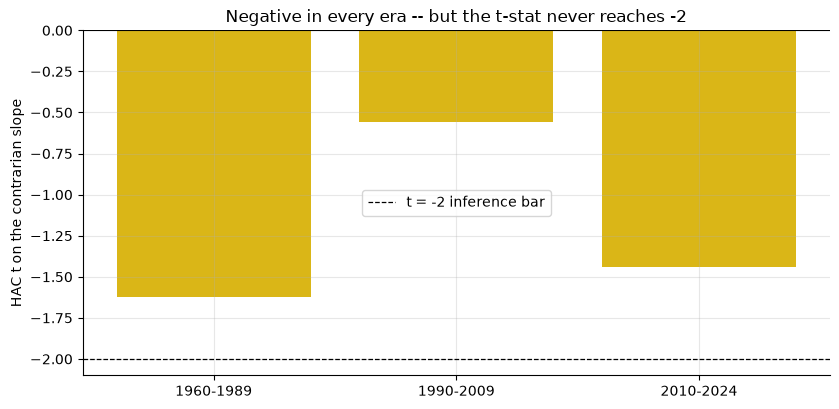

   period  slope_pct         t  n
1960-1989  -2.666522 -1.623817 30
1990-2009  -2.145049 -0.555249 20
2010-2024  -2.107413 -1.439634 15


In [6]:
rows = []
if HAVE_REAL:
    for label, a, b in [('1960-1989',1960,1989),('1990-2009',1990,2009),('2010-2024',2010,2024)]:
        sub = panel[(panel['year']>=a)&(panel['year']<=b)]
        r = st.predictive_regression(sub)
        rows.append({'period': label, 'slope_pct': r['beta']*100, 't': r['beta_t'], 'n': r['n']})
else:
    rows = [{'period':'1960-1989','slope_pct':-2.67,'t':R['sub1_t'],'n':30},
            {'period':'1990-2009','slope_pct':-2.15,'t':R['sub2_t'],'n':20},
            {'period':'2010-2024','slope_pct':-2.11,'t':R['sub3_t'],'n':15}]
sub_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
colors = [GREEN if abs(t) >= 2 else AMBER for t in sub_df['t']]
ax.bar(sub_df['period'], sub_df['t'], color=colors)
ax.axhline(-2.0, c='k', ls='--', lw=0.9, label='t = -2 inference bar')
ax.axhline(0, c='k', lw=0.8)
ax.set_ylabel('HAC t on the contrarian slope')
ax.set_title('Negative in every era -- but the t-stat never reaches -2')
ax.legend(); plt.tight_layout(); plt.show()
print(sub_df.to_string(index=False))

The slope is negative in **all three** sub-periods -- a genuinely robust *direction* -- yet the *t* never reaches -2. A stable-sign, never-significant effect is the signature of a weak-but-real-ish prior with no exploitable edge.

### 4e - The tradable rule vs buy-and-hold

Cash for the year after a surge (z > 1); else hold the S&P; net of 10 bps/switch.

In [7]:
if HAVE_REAL:
    bt = st.contrarian_timing_backtest(panel, surge_z=1.0, one_way_bps=10.0)
    bah, strat, cash, short = bt['bah_ann']*100, bt['strat_net_ann']*100, bt['years_in_cash'], bt['shortfall_net_pp']
else:
    bah, strat, cash, short = R['bah_ann'], R['strat_net_ann'], R['years_cash'], R['shortfall_pp']

print(f'Buy & hold (price-only):   {bah:+.2f}%/yr')
print(f'Contrarian rule (net):     {strat:+.2f}%/yr')
print(f'Years in cash: {cash}    Shortfall: {short:+.2f}pp/yr')
print()
print('The rule underperforms gross AND net -- there is no edge to monetize.')

Buy & hold (price-only):   +7.53%/yr
Contrarian rule (net):     +6.51%/yr
Years in cash: 8    Shortfall: -1.02pp/yr

The rule underperforms gross AND net -- there is no edge to monetize.


## 5 - The verdict

- **Signal `WEAK`** -- contrarian sign confirmed and stable across all eras, rhyming with the 2000/2007/2021 tops, but HAC *t* = -1.35 (regression), -0.67 (terciles), -1.22 (record event) -- none clears \|t\| >= 2. Folklore + right-but-insignificant tape = **Weak**.
- **Tradability `MIRAGE`** -- the contrarian timing rule loses to buy-and-hold by ~1pp/yr; the signal is a coincident by-product of rising prices, not a leading indicator.

## 6 - Could you trade it? -- the buy-and-hold benchmark

Cumulative wealth: the rule vs passive holding (uses real tape when cached).

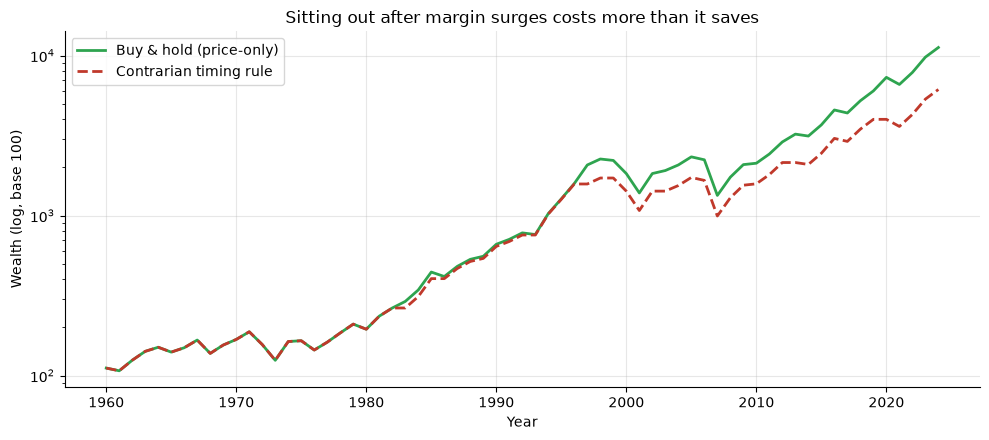

Terminal wealth -- buy&hold: 11232  rule: 6138


In [8]:
if HAVE_REAL:
    p = panel.dropna(subset=['yoy','fwd_ret']).reset_index(drop=True)
    z = st.standardized_yoy(p)
    inmkt = (z <= 1.0).to_numpy()
    fwd = p['fwd_ret'].to_numpy()
    strat_ret = np.where(inmkt, fwd, 0.0)
    yrs = p['year'].to_numpy()
    bah_c = np.cumprod(1+fwd)*100
    strat_c = np.cumprod(1+strat_ret)*100
else:
    rng = np.random.default_rng(260)
    yrs = np.arange(R['year_start'], R['year_end']+1)
    fwd = rng.normal(R['bah_ann']/100, 0.16, R['n'])
    strat_ret = fwd.copy(); strat_ret[rng.choice(R['n'], R['years_cash'], replace=False)] = 0.0
    bah_c = np.cumprod(1+fwd)*100; strat_c = np.cumprod(1+strat_ret)*100

fig, ax = plt.subplots(figsize=(10.0, 4.5))
ax.plot(yrs, bah_c, lw=2, c=GREEN, label='Buy & hold (price-only)')
ax.plot(yrs, strat_c, lw=2, c=RED, ls='--', label='Contrarian timing rule')
ax.set_yscale('log')
ax.set_xlabel('Year'); ax.set_ylabel('Wealth (log, base 100)')
ax.set_title('Sitting out after margin surges costs more than it saves')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Terminal wealth -- buy&hold: {bah_c[-1]:.0f}  rule: {strat_c[-1]:.0f}')

> The rule's equity curve drifts below buy-and-hold: the up-years it skips outweigh the crashes it dodges. (Price-only here; total return widens the gap.)

## 7 - Going further -- the synthetic positive control

Does the engine detect a contrarian signal *when one exists*? Plant a forward `predictive_beta` in a synthetic tape and sweep it.

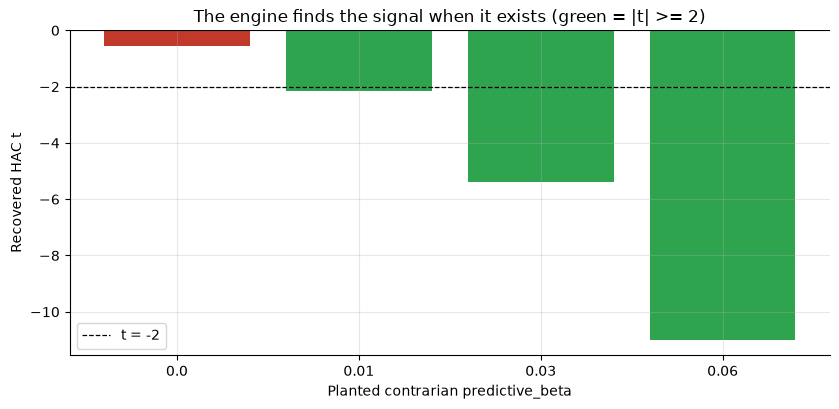

 planted_beta     slope          t
         0.00 -0.004524  -0.569909
         0.01 -0.017003  -2.138530
         0.03 -0.042657  -5.381604
         0.06 -0.086172 -11.002947

Null (beta=0) reads ~0; planted betas light up at t = -5 to -11.
The real tape carries no signal that strong -- the verdict is about the
MARKET, not the method.


In [9]:
betas = [0.0, 0.01, 0.03, 0.06]
out = []
for pb in betas:
    df, _ = data.synthetic_series(n_years=400, predictive_beta=pb, seed=260)
    df = df.dropna(subset=['yoy']).copy()
    df['fwd_ret'] = df['index_ret'].shift(-1)
    df = df.dropna(subset=['fwd_ret'])
    r = st.predictive_regression(df)
    out.append({'planted_beta': pb, 'slope': r['beta'], 't': r['beta_t']})
res = pd.DataFrame(out)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
colors = [GREEN if abs(t) >= 2 else RED for t in res['t']]
ax.bar([str(b) for b in res['planted_beta']], res['t'], color=colors)
ax.axhline(-2.0, c='k', ls='--', lw=0.9, label='t = -2')
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('Planted contrarian predictive_beta'); ax.set_ylabel('Recovered HAC t')
ax.set_title('The engine finds the signal when it exists (green = |t| >= 2)')
ax.legend(); plt.tight_layout(); plt.show()
print(res.to_string(index=False))
print()
print('Null (beta=0) reads ~0; planted betas light up at t = -5 to -11.')
print('The real tape carries no signal that strong -- the verdict is about the')
print('MARKET, not the method.')

The machinery is truthful: ~zero on the null, strongly negative when a real contrarian effect is planted. The real margin-debt tape just doesn't carry one big enough to clear the inference bar. **Weak / Mirage.**